In [51]:
# 气候数据可视化复现
# 在notebook中显示图表
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')  # 忽略所有警告

sys.path.append('../code')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# 设置中文字体
MAC_CHINESE_FONTS = ['STHeiti', 'PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['font.sans-serif'] = MAC_CHINESE_FONTS + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# 设置Seaborn风格
sns.set_theme(style="ticks", context="talk")

# 数据路径
DATA_DIR = Path('../data/raw')
OUTPUT_DIR = Path('../output/notebook_figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 是否保存图片（设为False时只显示不保存）
SAVE_FIGURES = False


In [52]:
# 加载数据
from data_loader import ClimateDataLoader
from io import StringIO
import sys

# 临时重定向stdout以静默加载
old_stdout = sys.stdout
sys.stdout = StringIO()

loader = ClimateDataLoader(data_dir=str(DATA_DIR))
df_global = loader.load_global_temperatures()
df_country = loader.load_country_temperatures()
df_city = loader.load_city_temperatures(major_cities_only=True)

# 恢复stdout
sys.stdout = old_stdout


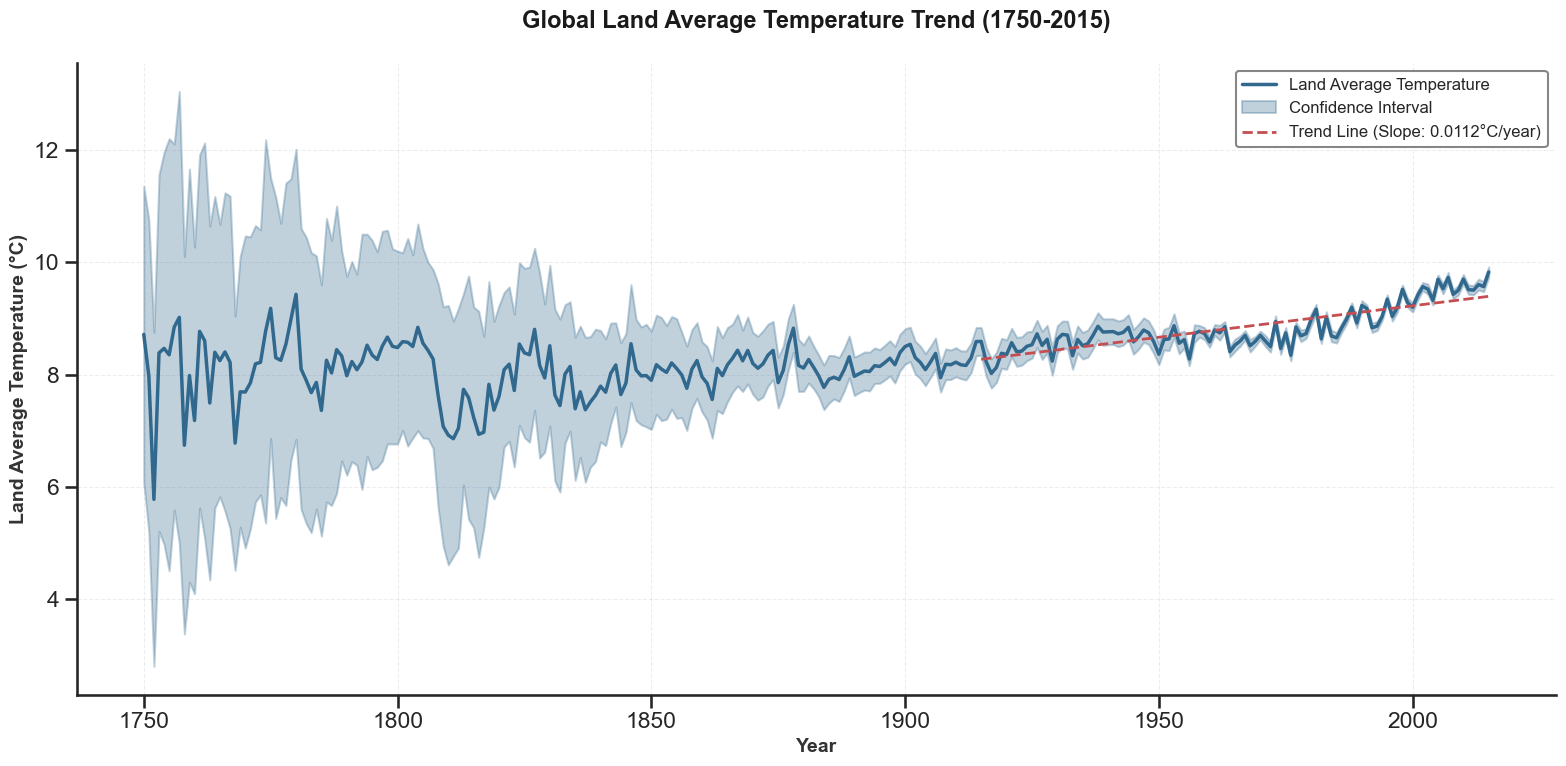

In [53]:
# 图1: 全球温度趋势
# 按年份聚合
df_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean',
    'LandAverageTemperatureUncertainty': 'mean'
}).reset_index()
df_yearly = df_yearly.dropna()

fig, ax = plt.subplots(figsize=(16, 8))

# 绘制主线
viridis_colors = sns.color_palette("viridis", 2)
ax.plot(df_yearly['year'], df_yearly['LandAverageTemperature'],
       linewidth=2.5, color=viridis_colors[0], label='Land Average Temperature')

# 绘制置信区间
ax.fill_between(
    df_yearly['year'],
    df_yearly['LandAverageTemperature'] - df_yearly['LandAverageTemperatureUncertainty'],
    df_yearly['LandAverageTemperature'] + df_yearly['LandAverageTemperatureUncertainty'],
    alpha=0.3, color=viridis_colors[0], label='Confidence Interval'
)

# 添加趋势线（最近100年）
recent_df = df_yearly[df_yearly['year'] >= df_yearly['year'].max() - 100]
z = np.polyfit(recent_df['year'], recent_df['LandAverageTemperature'], 1)
p = np.poly1d(z)
ax.plot(recent_df['year'], p(recent_df['year']), 
       'r--', linewidth=2, label=f'Trend Line (Slope: {z[0]:.4f}°C/year)')

ax.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('Land Average Temperature (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('Global Land Average Temperature Trend (1750-2015)', 
            fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '01_global_temperature_trend.png', dpi=300, bbox_inches='tight')


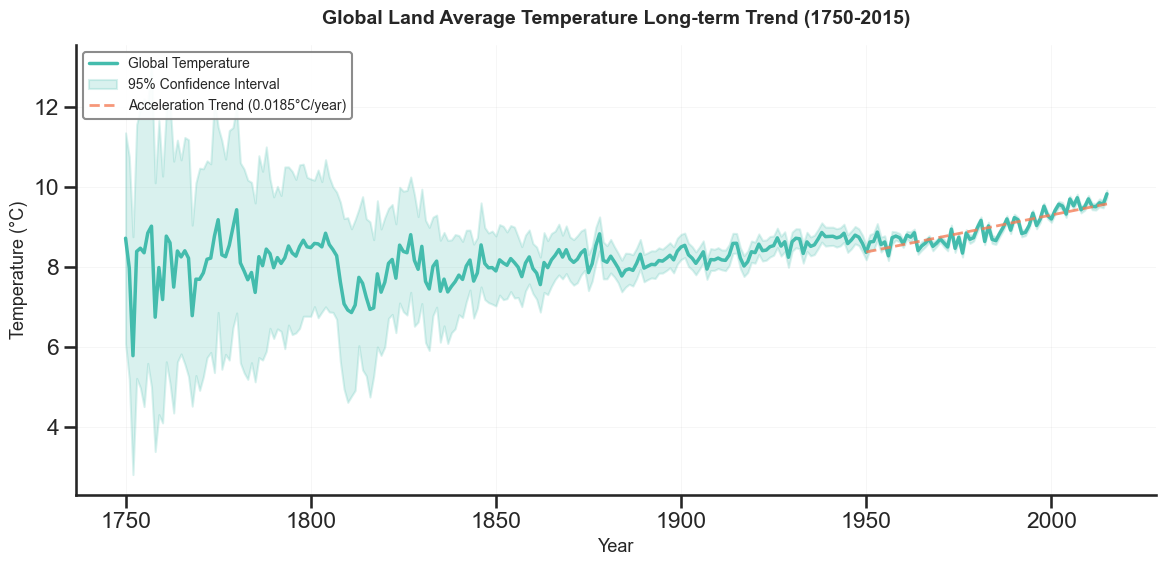

In [54]:
# 图2: 温度带图
# 数据准备
df_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean',
    'LandAverageTemperatureUncertainty': 'mean'
}).reset_index().dropna()

# 创建图表
fig, ax = plt.subplots(figsize=(12, 6))

# 配色方案
COLORS = {
    'mako': sns.color_palette("mako", n_colors=10),
    'rocket': sns.color_palette("rocket", n_colors=10),
}

# 主线 - 使用 mako 深色
ax.plot(df_yearly['year'], df_yearly['LandAverageTemperature'],
       linewidth=2.5, color=COLORS['mako'][7], label='Global Temperature', zorder=3)

# 置信带 - 半透明
ax.fill_between(
    df_yearly['year'],
    df_yearly['LandAverageTemperature'] - df_yearly['LandAverageTemperatureUncertainty'],
    df_yearly['LandAverageTemperature'] + df_yearly['LandAverageTemperatureUncertainty'],
    alpha=0.2, color=COLORS['mako'][7], label='95% Confidence Interval', zorder=2
)

# 趋势线（1950后）- 使用 rocket 亮色
recent = df_yearly[df_yearly['year'] >= 1950]
z = np.polyfit(recent['year'], recent['LandAverageTemperature'], 1)
p = np.poly1d(z)
ax.plot(recent['year'], p(recent['year']), 
       linestyle='--', linewidth=2, color=COLORS['rocket'][7],
       label=f'Acceleration Trend ({z[0]:.4f}°C/year)', alpha=0.8, zorder=3)

# 样式设置
ax.set_xlabel('Year', fontsize=13, weight='medium')
ax.set_ylabel('Temperature (°C)', fontsize=13, weight='medium')
ax.set_title('Global Land Average Temperature Long-term Trend (1750-2015)', 
            fontsize=14, weight='bold', pad=15)

# 图例
ax.legend(loc='upper left', fontsize=10, frameon=True, 
         framealpha=0.9, edgecolor='gray', facecolor='white')

# 网格
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)

# 去掉上右边框
sns.despine()

plt.tight_layout()
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '01_temperature_bands.png', dpi=300, bbox_inches='tight')


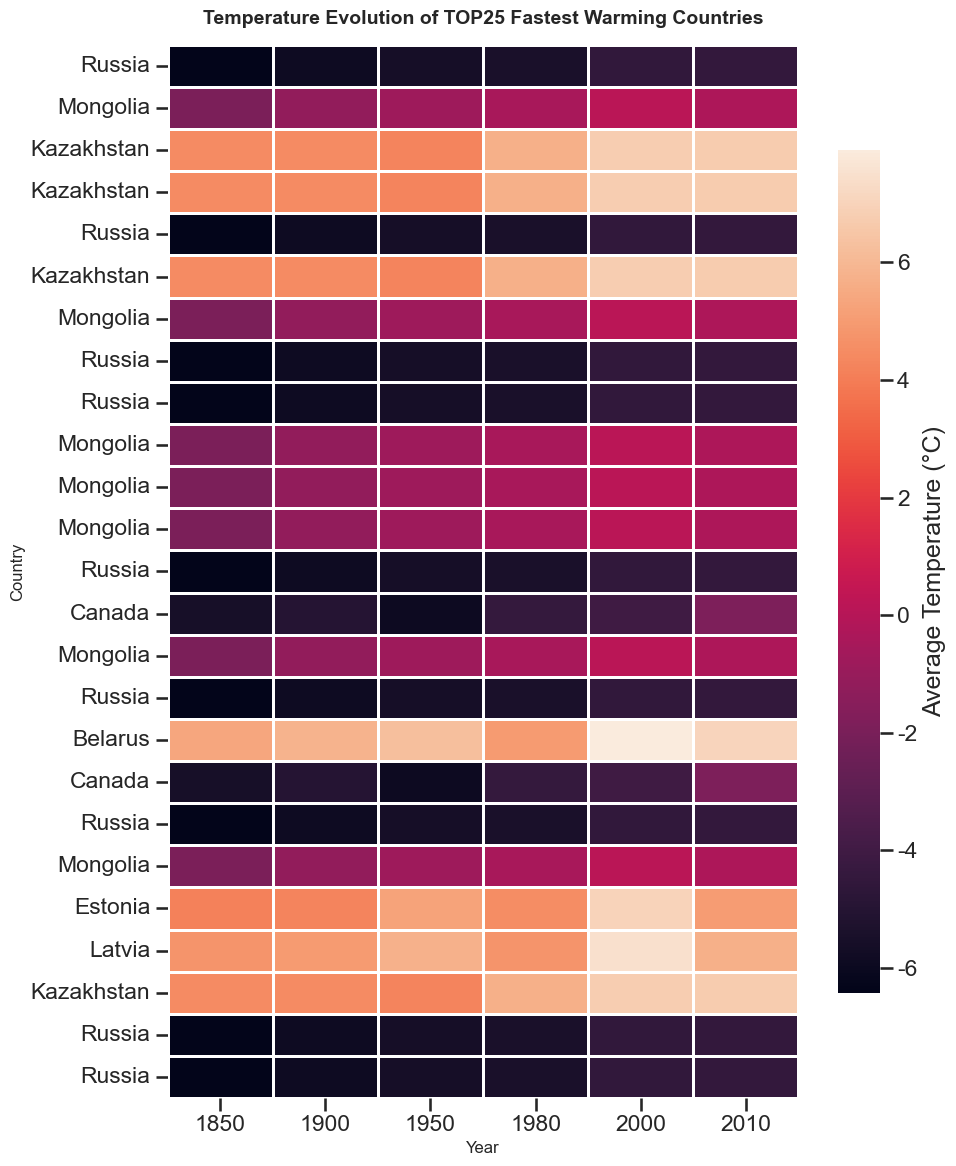

In [55]:
# 图3: 国家热力图
# 选择TOP25变化最大的国家
key_years = [1850, 1900, 1950, 1980, 2000, 2010]

df_2010 = df_country[df_country['year'] == 2010].copy()
df_1850 = df_country[df_country['year'] == 1850].copy()
df_change = df_2010.merge(df_1850, on='Country', suffixes=('_2010', '_1850'))
df_change['temp_change'] = (df_change['AverageTemperature_2010'] - 
                            df_change['AverageTemperature_1850'])
top_countries = df_change.nlargest(25, 'temp_change')['Country'].tolist()

# 准备数据
heatmap_data = []
for country in top_countries:
    temps = []
    for year in key_years:
        df_filtered = df_country[(df_country['Country'] == country) & 
                                (df_country['year'] == year)]
        if not df_filtered.empty:
            temps.append(df_filtered['AverageTemperature'].mean())
        else:
            temps.append(np.nan)
    heatmap_data.append(temps)

heatmap_df = pd.DataFrame(heatmap_data, index=top_countries, columns=key_years)

# 绘制
fig, ax = plt.subplots(figsize=(10, 12))

# 使用 rocket 配色，调整 vmin/vmax 让对比度更明显
data_min = heatmap_df.min().min()
data_max = heatmap_df.max().max()

sns.heatmap(heatmap_df, cmap='rocket', annot=False,
           linewidths=1, linecolor='white', 
           cbar_kws={'label': 'Average Temperature (°C)', 'shrink': 0.8},
           ax=ax, vmin=data_min, vmax=data_max, robust=True)

ax.set_xlabel('Year', fontsize=12, weight='medium')
ax.set_ylabel('Country', fontsize=12, weight='medium')
ax.set_title('Temperature Evolution of TOP25 Fastest Warming Countries', 
            fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '02_country_heatmap_pro.png', dpi=300, bbox_inches='tight')


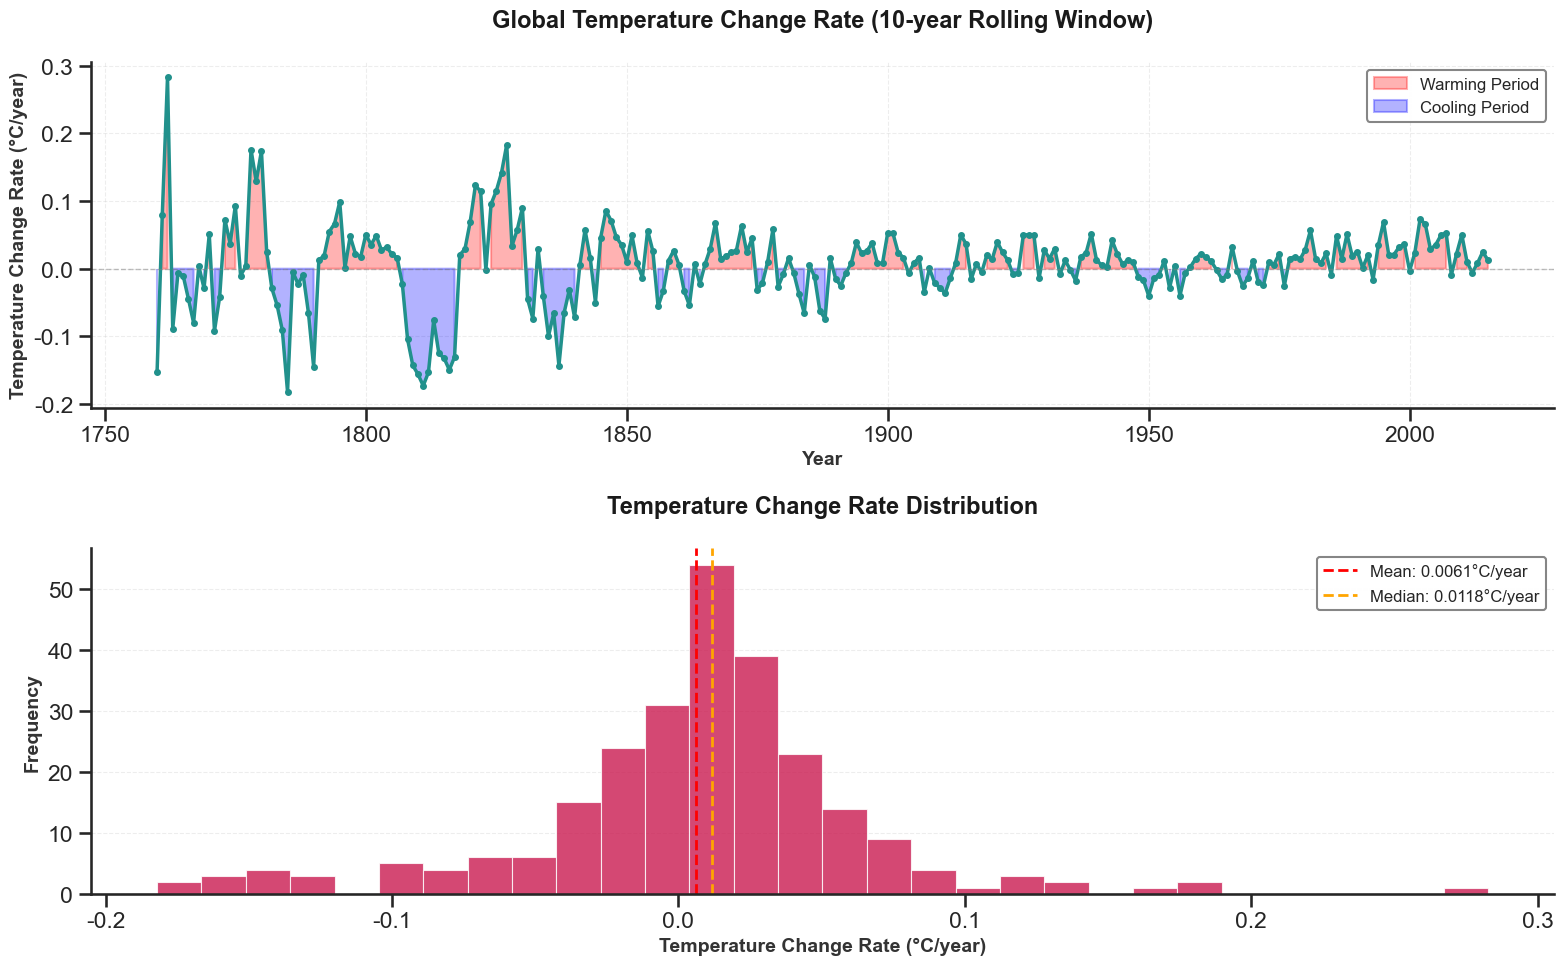

In [56]:
# 图4: 温度变化速率
# 按10年窗口计算温度变化速率
df_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
df_yearly = df_yearly.dropna()

# 计算每10年的变化速率
window = 10
change_rates = []
years = []

for i in range(window, len(df_yearly)):
    start_temp = df_yearly.iloc[i-window]['LandAverageTemperature']
    end_temp = df_yearly.iloc[i]['LandAverageTemperature']
    start_year = df_yearly.iloc[i-window]['year']
    end_year = df_yearly.iloc[i]['year']
    
    rate = (end_temp - start_temp) / window  # °C/年
    change_rates.append(rate)
    years.append(end_year)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# 子图1：变化速率时间序列
viridis_colors = sns.color_palette("viridis", 1)
ax1.plot(years, change_rates, linewidth=2.5, color=viridis_colors[0], marker='o', markersize=4)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.fill_between(years, 0, change_rates, where=np.array(change_rates) > 0, 
                alpha=0.3, color='red', label='Warming Period')
ax1.fill_between(years, 0, change_rates, where=np.array(change_rates) < 0, 
                alpha=0.3, color='blue', label='Cooling Period')

ax1.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
ax1.set_ylabel('Temperature Change Rate (°C/year)', fontsize=14, fontweight='bold', color='#333333')
ax1.set_title('Global Temperature Change Rate (10-year Rolling Window)', 
             fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax1.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax1.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 子图2：变化速率分布直方图
rocket_colors = sns.color_palette("rocket_r", 1)
ax2.hist(change_rates, bins=30, color=rocket_colors[0], edgecolor='white', 
        linewidth=0.8, alpha=0.8)
ax2.axvline(np.mean(change_rates), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(change_rates):.4f}°C/year')
ax2.axvline(np.median(change_rates), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {np.median(change_rates):.4f}°C/year')

ax2.set_xlabel('Temperature Change Rate (°C/year)', fontsize=14, fontweight='bold', color='#333333')
ax2.set_ylabel('Frequency', fontsize=14, fontweight='bold', color='#333333')
ax2.set_title('Temperature Change Rate Distribution', fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax2.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax2.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '06_temperature_change_rate.png', dpi=300, bbox_inches='tight')


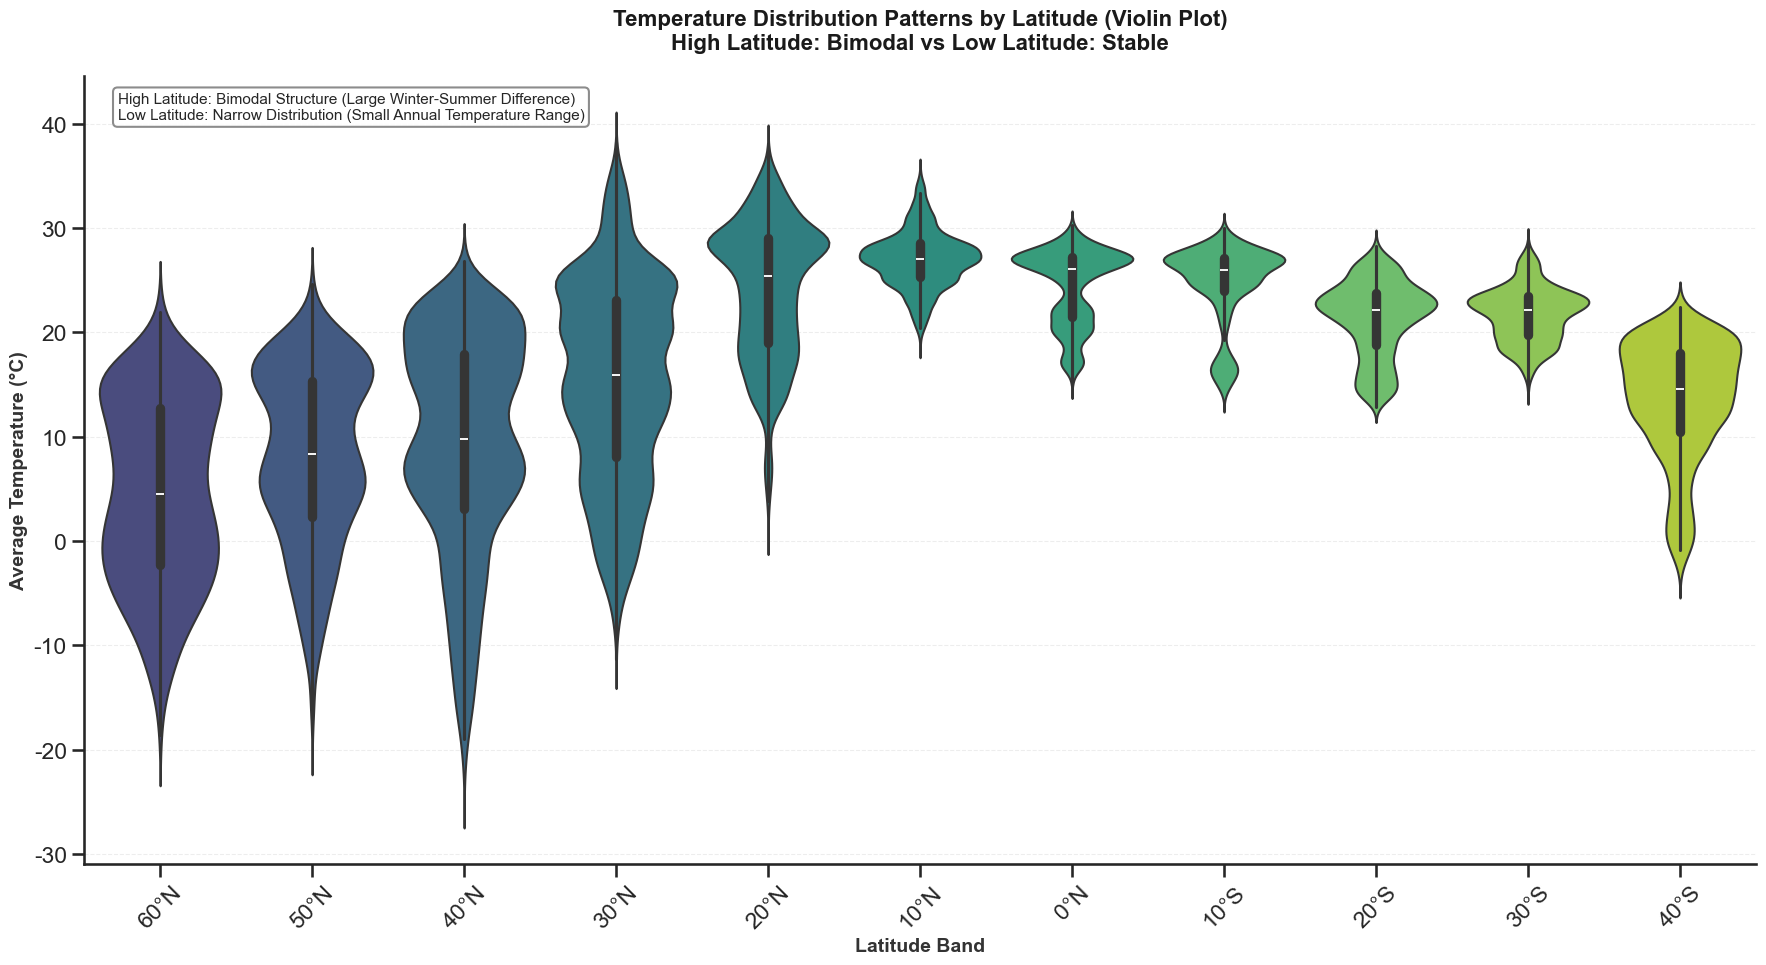

In [57]:
# 图5: 纬度小提琴图
# 过滤最近50年的数据
df_recent = df_city[df_city['year'] >= df_city['year'].max() - 50].copy()

# 创建纬度带（每10度一个区间）
def assign_latitude_band(lat):
    if pd.isna(lat):
        return None
    lat_rounded = int(lat // 10) * 10
    if lat >= 0:
        return f"{lat_rounded}°N"
    else:
        return f"{-lat_rounded}°S"

df_recent['latitude_band'] = df_recent['Latitude_num'].apply(assign_latitude_band)
df_recent = df_recent.dropna(subset=['latitude_band', 'AverageTemperature'])

# 按纬度排序
def parse_latitude_for_sort(lat_str):
    """解析纬度字符串用于排序"""
    if '°N' in lat_str:
        return float(lat_str.replace('°N', ''))
    elif '°S' in lat_str:
        return -float(lat_str.replace('°S', ''))
    return 0

latitude_order = sorted(df_recent['latitude_band'].unique(), 
                       key=parse_latitude_for_sort, 
                       reverse=True)

fig, ax = plt.subplots(figsize=(18, 10))

# 绘制小提琴图（使用 viridis 渐变）
viridis_cmap = sns.color_palette("viridis", as_cmap=True)
violin_colors = viridis_cmap(np.linspace(0.2, 0.9, len(latitude_order)))
# 将numpy数组转换为列表，避免警告
violin_colors_list = [tuple(c) for c in violin_colors]
sns.violinplot(data=df_recent, x='latitude_band', y='AverageTemperature',
              order=latitude_order, palette=violin_colors_list,
              inner='box', linewidth=1.5, ax=ax)

ax.set_xlabel('Latitude Band', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('Average Temperature (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('Temperature Distribution Patterns by Latitude (Violin Plot)\nHigh Latitude: Bimodal vs Low Latitude: Stable',
            fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
ax.tick_params(axis='x', rotation=45)

# 添加注释
ax.text(0.02, 0.98, 'High Latitude: Bimodal Structure (Large Winter-Summer Difference)\nLow Latitude: Narrow Distribution (Small Annual Temperature Range)', 
       transform=ax.transAxes, fontsize=11, va='top', ha='left',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# 美化
ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '04_latitude_violin.png', dpi=300, bbox_inches='tight')


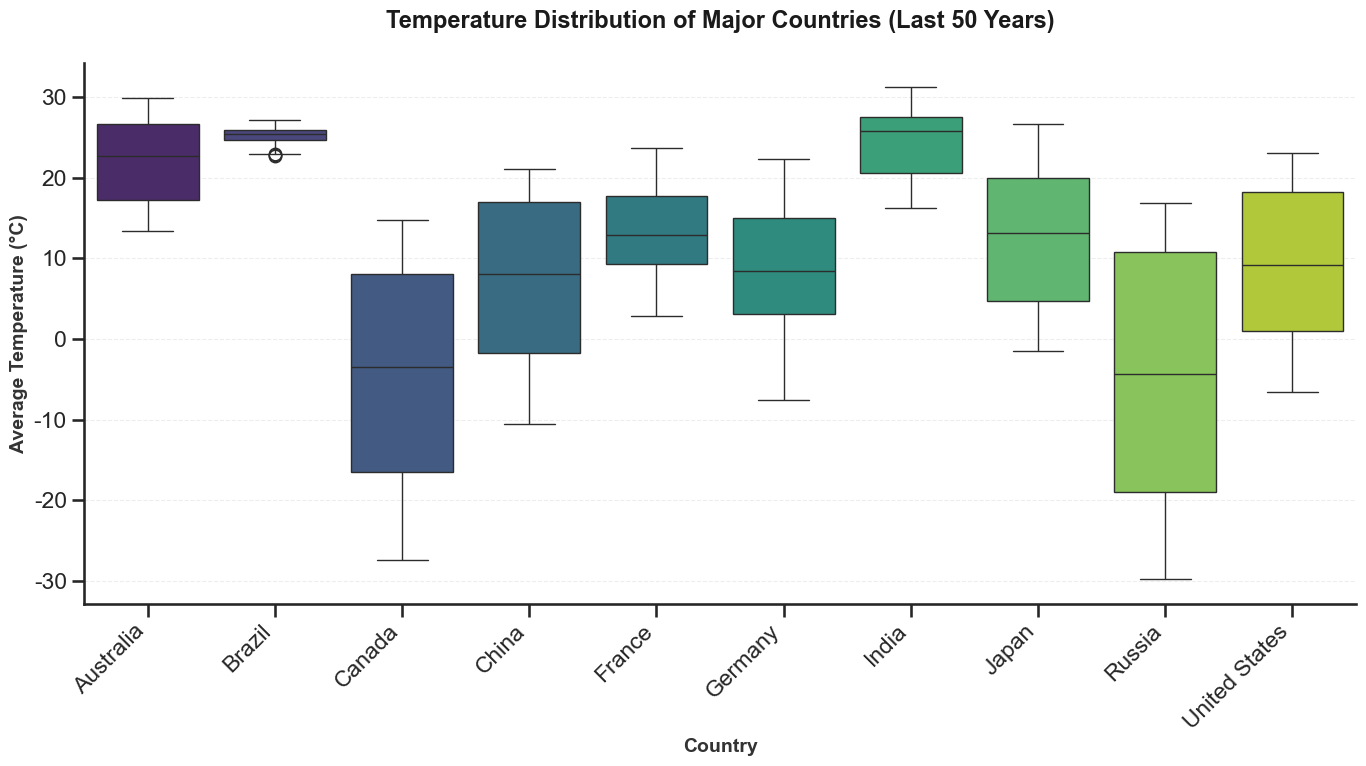

In [58]:
# 图6: 温度分布箱线图
# 选择部分国家
countries = ['China', 'United States', 'Russia', 'India', 'Brazil', 
            'Canada', 'Australia', 'Germany', 'France', 'Japan']
df_selected = df_country[df_country['Country'].isin(countries)]

# 只使用最近50年数据
max_year = df_selected['year'].max()
df_selected = df_selected[df_selected['year'] >= max_year - 50]

fig, ax = plt.subplots(figsize=(14, 8))

viridis_palette = sns.color_palette("viridis", len(countries))
sns.boxplot(data=df_selected, x='Country', y='AverageTemperature',
           palette=viridis_palette, ax=ax)

ax.set_xlabel('Country', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('Average Temperature (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('Temperature Distribution of Major Countries (Last 50 Years)', 
            fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '05_temperature_distribution.png', dpi=300, bbox_inches='tight')


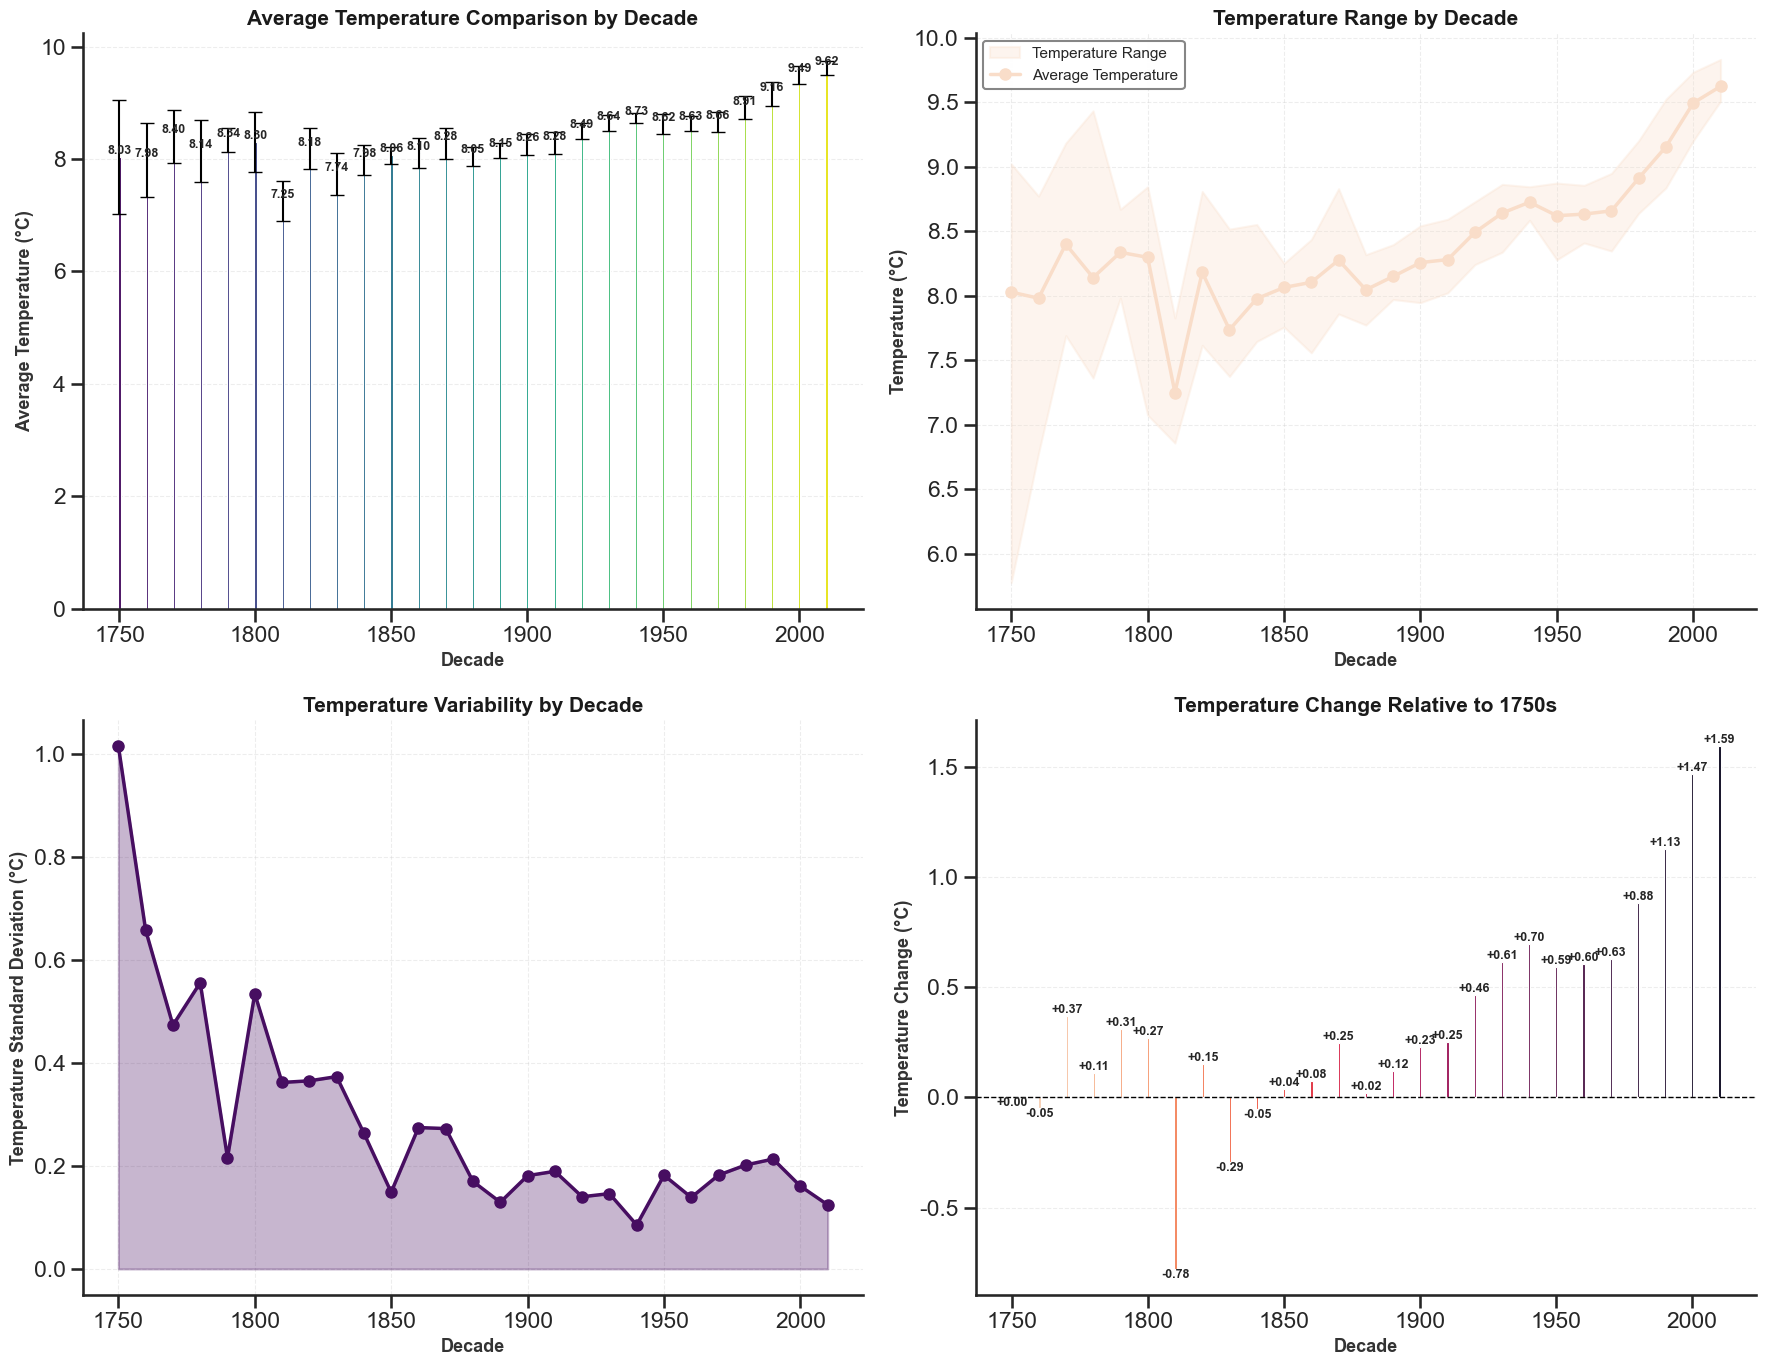

In [59]:
# 图7: 年代对比分析
# 按年份聚合
df_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
df_yearly = df_yearly.dropna()

# 按年代分组
df_yearly['decade'] = (df_yearly['year'] // 10) * 10
df_decade = df_yearly.groupby('decade')['LandAverageTemperature'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# 子图1：年代平均温度
viridis_colors = sns.color_palette("viridis", len(df_decade))
bars1 = ax1.bar(df_decade['decade'], df_decade['mean'],
               color=viridis_colors, edgecolor='white', linewidth=0.8)
ax1.errorbar(df_decade['decade'], df_decade['mean'], yerr=df_decade['std'],
             fmt='none', color='black', capsize=5, linewidth=1.5)

ax1.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax1.set_ylabel('Average Temperature (°C)', fontsize=13, fontweight='bold', color='#333333')
ax1.set_title('Average Temperature Comparison by Decade', fontsize=15, fontweight='bold', color='#1a1a1a')
ax1.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 添加数值标签
for bar, mean_val in zip(bars1, df_decade['mean']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean_val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 子图2：温度范围（min-max）
rocket_colors = sns.color_palette("rocket_r", len(df_decade))
ax2.fill_between(df_decade['decade'], df_decade['min'], df_decade['max'],
                alpha=0.3, color=rocket_colors[0], label='Temperature Range')
ax2.plot(df_decade['decade'], df_decade['mean'], 'o-', linewidth=2.5,
        color=rocket_colors[0], markersize=8, label='Average Temperature')

ax2.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax2.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold', color='#333333')
ax2.set_title('Temperature Range by Decade', fontsize=15, fontweight='bold', color='#1a1a1a')
ax2.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax2.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 子图3：温度标准差（波动性）
ax3.plot(df_decade['decade'], df_decade['std'], 'o-', linewidth=2.5,
        color=viridis_colors[0], markersize=8)
ax3.fill_between(df_decade['decade'], 0, df_decade['std'],
                alpha=0.3, color=viridis_colors[0])

ax3.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax3.set_ylabel('Temperature Standard Deviation (°C)', fontsize=13, fontweight='bold', color='#333333')
ax3.set_title('Temperature Variability by Decade', fontsize=15, fontweight='bold', color='#1a1a1a')
ax3.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 子图4：温度变化趋势（相对于第一个年代）
first_decade_temp = df_decade.iloc[0]['mean']
df_decade['change_from_first'] = df_decade['mean'] - first_decade_temp

bars4 = ax4.bar(df_decade['decade'], df_decade['change_from_first'],
               color=rocket_colors, edgecolor='white', linewidth=0.8)
ax4.axhline(0, color='black', linestyle='--', linewidth=1)

ax4.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax4.set_ylabel('Temperature Change (°C)', fontsize=13, fontweight='bold', color='#333333')
ax4.set_title(f'Temperature Change Relative to {int(df_decade.iloc[0]["decade"])}s', 
             fontsize=15, fontweight='bold', color='#1a1a1a')
ax4.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# 添加数值标签
for bar, change in zip(bars4, df_decade['change_from_first']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{change:+.2f}', ha='center', 
            va='bottom' if height > 0 else 'top', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '12_decade_comparison.png', dpi=300, bbox_inches='tight')


In [60]:
# 所有图表已完成
